In [1]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def load_combined_results(folder):
    result_files = glob.glob(os.path.join(folder, "results_*_all.csv"))
    df_list = []
    for file in result_files:
        df = pd.read_csv(file)
        df["fn_type"] = folder
        df["architecture"] = os.path.basename(file).split("_")[1]
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

df_basic = load_combined_results("basic")
df_data = load_combined_results("data_local")
all_data = pd.concat([df_basic, df_data], ignore_index=True)


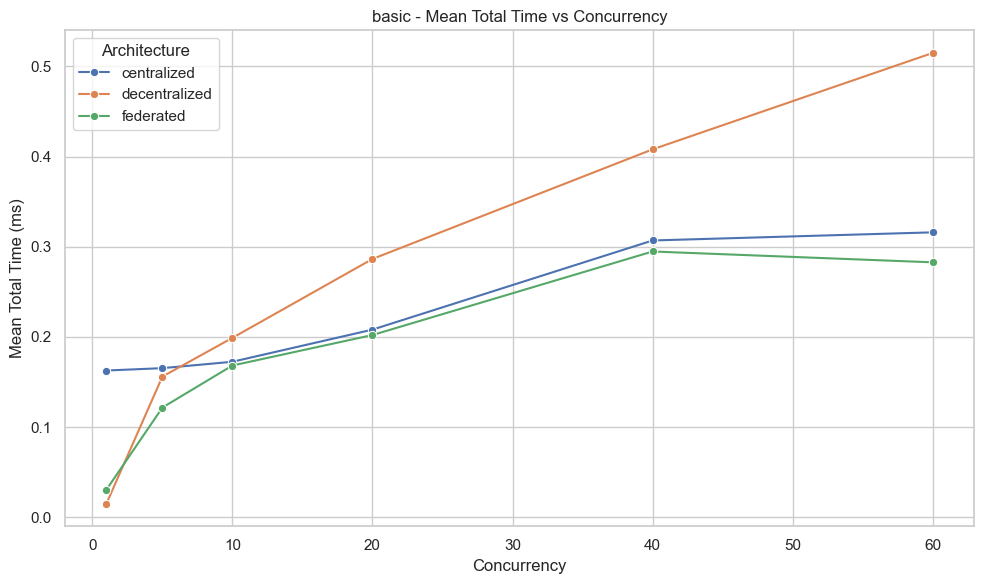

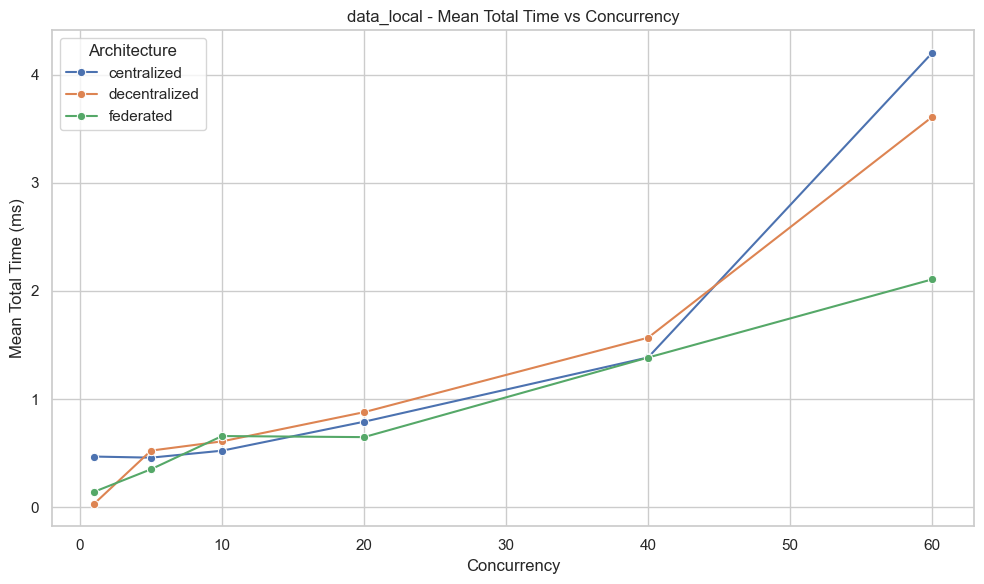

In [24]:
for fn in ["basic", "data_local"]:
    df = all_data[all_data["fn_type"] == fn]
    grouped = df.groupby(["architecture", "concurrency"])["total_time"].std().reset_index()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=grouped, x="concurrency", y="total_time", hue="architecture", marker="o")
    plt.title(f"{fn} - Mean Total Time vs Concurrency")
    plt.xlabel("Concurrency")
    plt.ylabel("Mean Total Time (ms)")
    plt.legend(title="Architecture")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


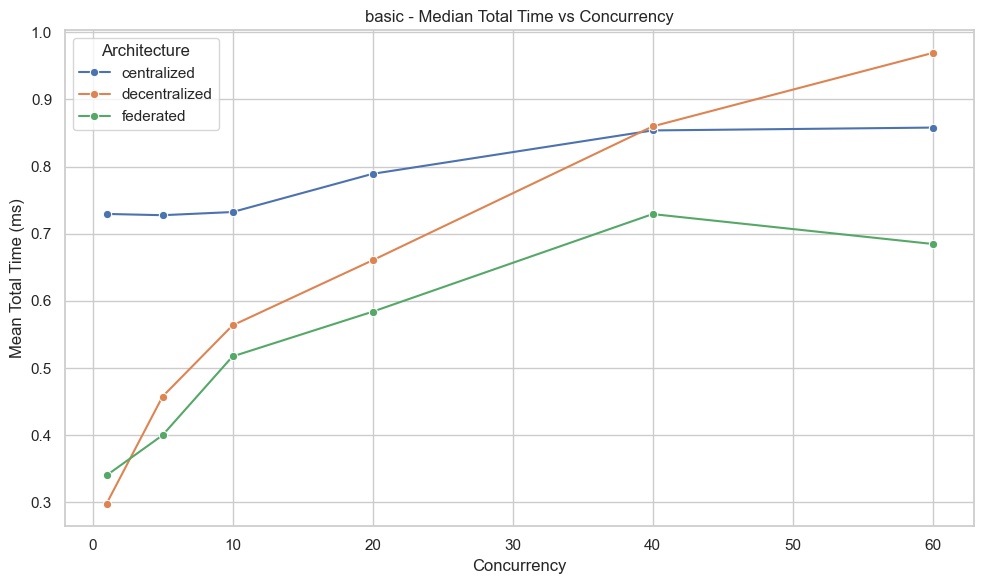

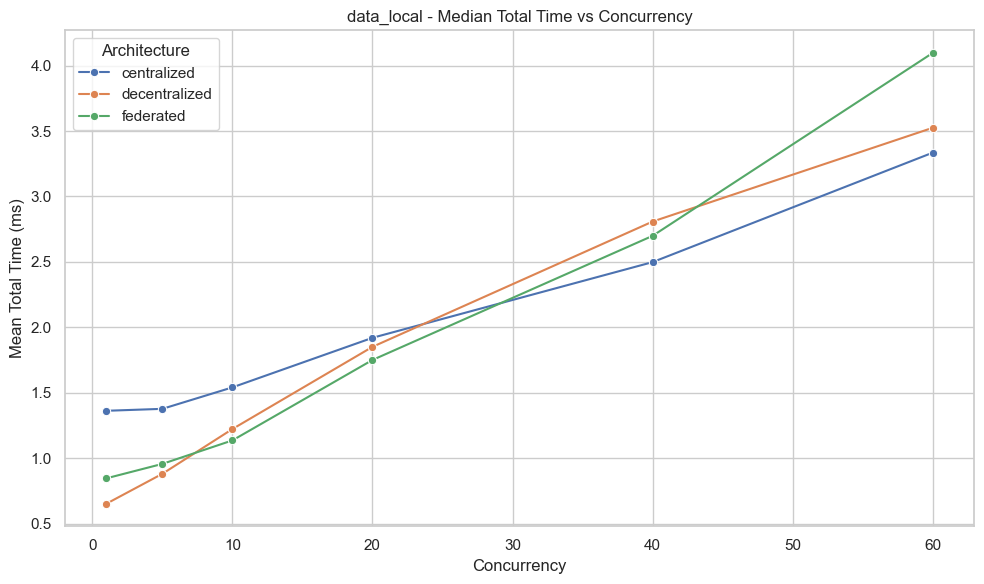

In [12]:
for fn in ["basic", "data_local"]:
    df = all_data[all_data["fn_type"] == fn]
    grouped = df.groupby(["architecture", "concurrency"])["total_time"].median().reset_index()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=grouped, x="concurrency", y="total_time", hue="architecture", marker="o")
    plt.title(f"{fn} - Median Total Time vs Concurrency")
    plt.xlabel("Concurrency")
    plt.ylabel("Mean Total Time (ms)")
    plt.legend(title="Architecture")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


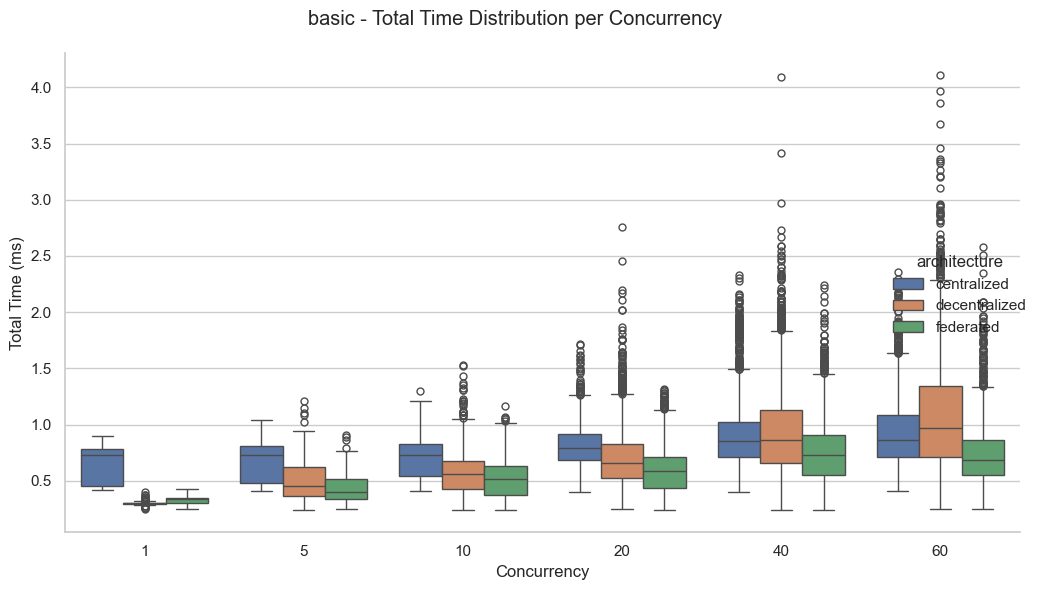

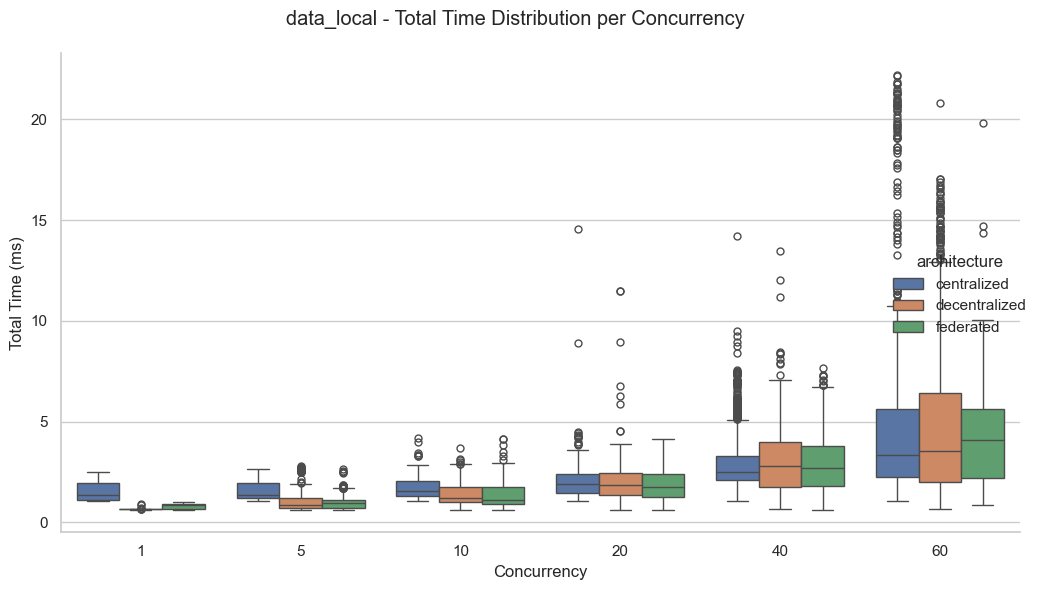

In [4]:
for fn in ["basic", "data_local"]:
    df = all_data[all_data["fn_type"] == fn]

    g = sns.catplot(
        data=df, x="concurrency", y="total_time", hue="architecture",
        kind="box", height=6, aspect=1.5
    )
    g.fig.suptitle(f"{fn} - Total Time Distribution per Concurrency")
    g.set_axis_labels("Concurrency", "Total Time (ms)")
    plt.tight_layout()
    plt.show()

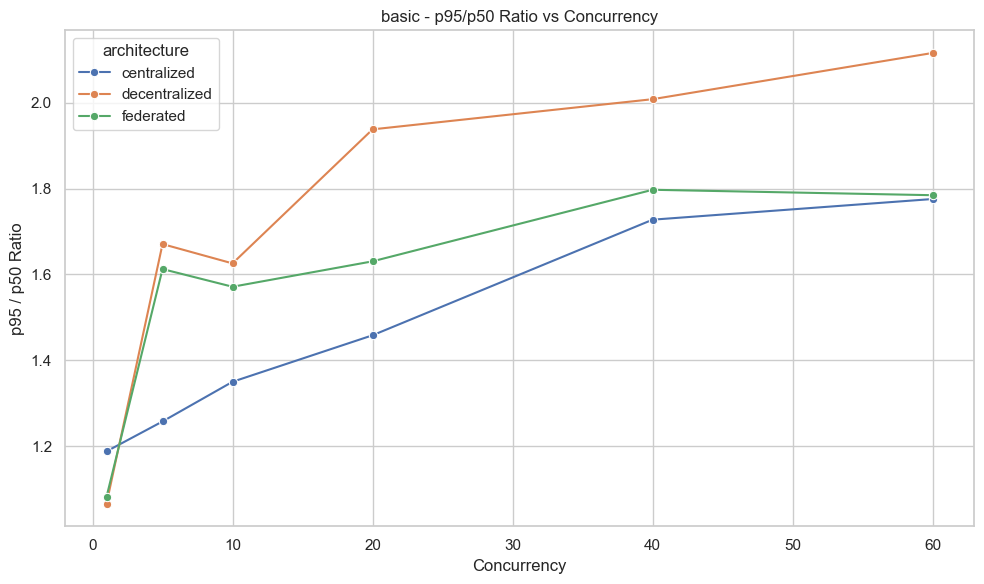

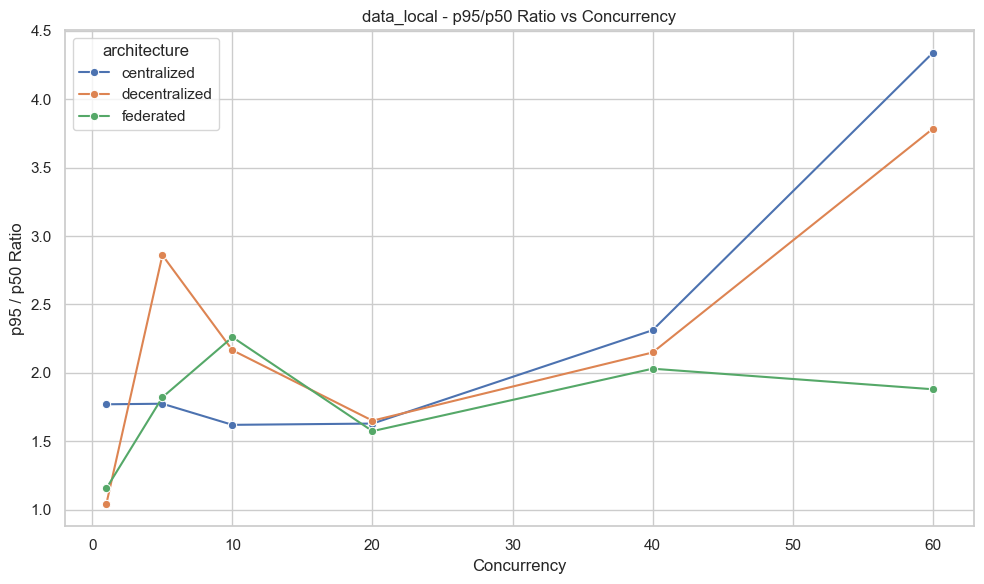

In [5]:
agg = all_data.groupby(["fn_type", "architecture", "concurrency"])["total_time"].agg([
    ("p50", lambda x: np.percentile(x, 50)),
    ("p95", lambda x: np.percentile(x, 95))
]).reset_index()
agg["p95/p50"] = agg["p95"] / agg["p50"]

# 绘图
for fn in ["basic", "data_local"]:
    df = agg[agg["fn_type"] == fn]

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="concurrency", y="p95/p50", hue="architecture", marker="o")
    plt.title(f"{fn} - p95/p50 Ratio vs Concurrency")
    plt.xlabel("Concurrency")
    plt.ylabel("p95 / p50 Ratio")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

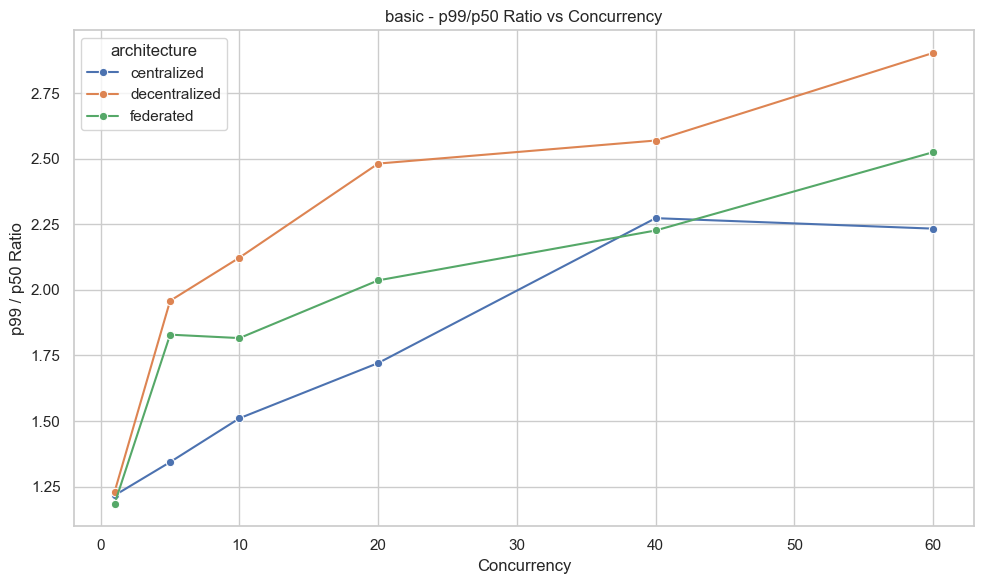

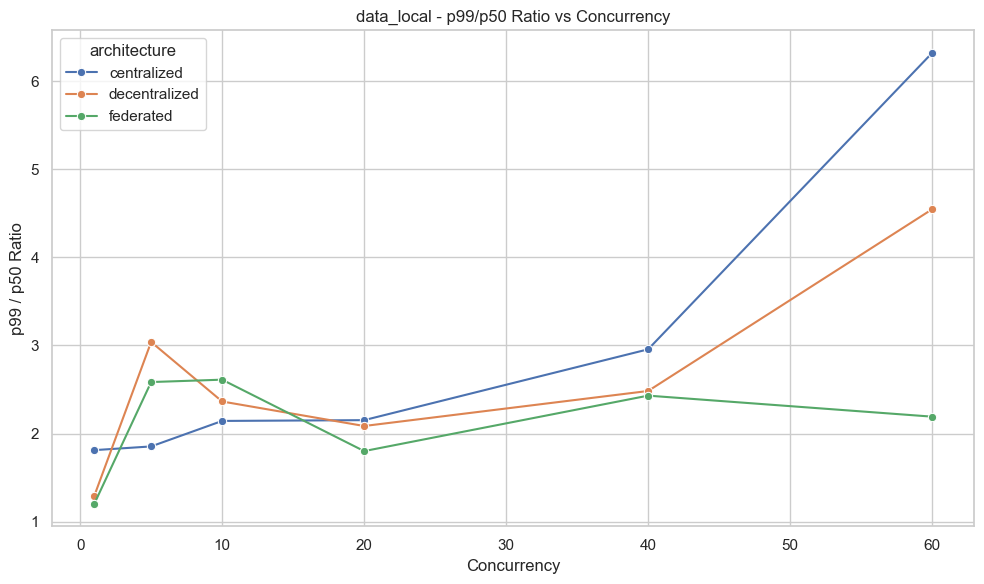

In [13]:
agg = all_data.groupby(["fn_type", "architecture", "concurrency"])["total_time"].agg([
    ("p50", lambda x: np.percentile(x, 50)),
    ("p99", lambda x: np.percentile(x, 99))
]).reset_index()
agg["p99/p50"] = agg["p99"] / agg["p50"]

for fn in ["basic", "data_local"]:
    df = agg[agg["fn_type"] == fn]

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="concurrency", y="p99/p50", hue="architecture", marker="o")
    plt.title(f"{fn} - p99/p50 Ratio vs Concurrency")
    plt.xlabel("Concurrency")
    plt.ylabel("p99 / p50 Ratio")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

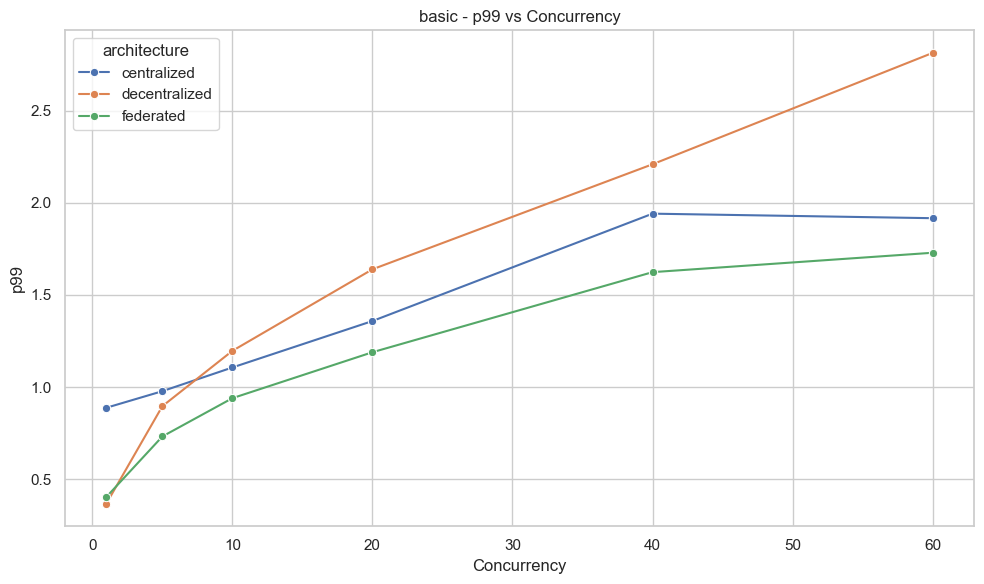

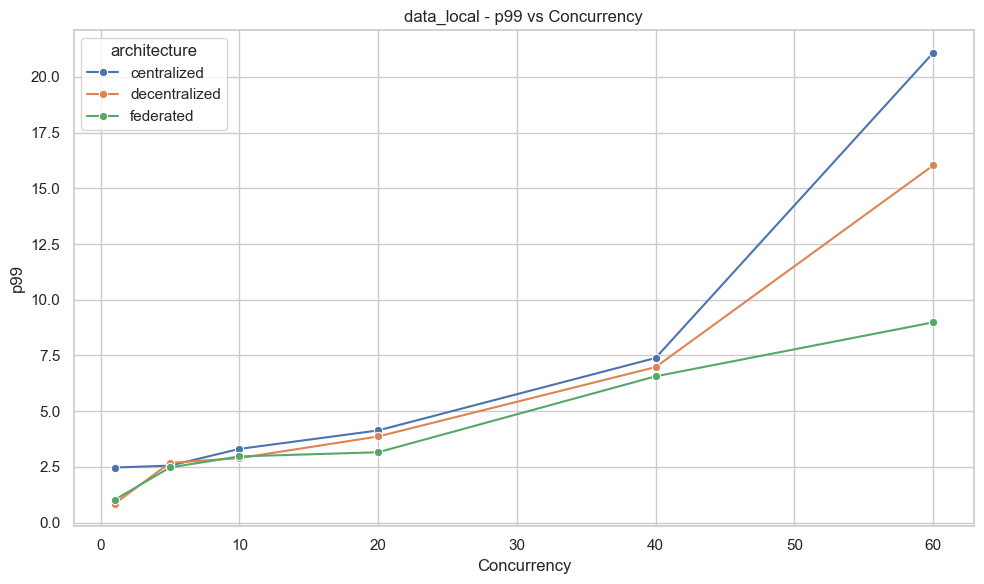

In [23]:
agg = all_data.groupby(["fn_type", "architecture", "concurrency"])["total_time"].agg([
    ("p50", lambda x: np.percentile(x, 50)),
    ("p99", lambda x: np.percentile(x, 99))
]).reset_index()
agg["p99"] = agg["p99"]

for fn in ["basic", "data_local"]:
    df = agg[agg["fn_type"] == fn]

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="concurrency", y="p99", hue="architecture", marker="o")
    plt.title(f"{fn} - p99 vs Concurrency")
    plt.xlabel("Concurrency")
    plt.ylabel("p99")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
import pandas as pd
import numpy as np

# 加载并合并所有静态架构数据
def load_static_data():
    dfs = []
    for fn in ["basic", "data_local"]:
        for arch in ["centralized", "federated", "decentralized"]:
            df = pd.read_csv(f"{fn}/results_{arch}_all.csv")
            df["architecture"] = arch
            df["fn_type"] = fn
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

df = load_static_data()

# 计算每组 (fn_type, architecture, concurrency) 的 p50, p95, mean
summary = df.groupby(["fn_type", "architecture", "concurrency"])["total_time"].agg([
    ("p50", lambda x: np.percentile(x, 50)),
    ("p95", lambda x: np.percentile(x, 95)),
    ("mean", "mean")
]).reset_index()

summary["r"] = summary["p95"] / summary["p50"]

# 网格搜索范围
soft_range = np.arange(1.1, 1.6, 0.1)
hard_range = np.arange(1.7, 2.6, 0.1)

def map_r_to_weight(r, c_soft, c_hard):
    if r < c_soft:
        return 0
    elif r > c_hard:
        return 1
    return (r - c_soft) / (c_hard - c_soft)

# 为每个 fn_type 分开计算
final_results = []

for fn_type in ["basic", "data_local"]:
    fn_df = summary[summary["fn_type"] == fn_type]
    records = []

    for c_soft in soft_range:
        for c_hard in hard_range:
            if c_hard <= c_soft:
                continue

            gap_total = 0
            count = 0

            for conc, group in fn_df.groupby("concurrency"):
                try:
                    r_map = {row["architecture"]: row["r"] for _, row in group.iterrows()}
                    perf_map = {row["architecture"]: row["mean"] for _, row in group.iterrows()}

                    fed_weight = map_r_to_weight(r_map["decentralized"], c_soft, c_hard)
                    cen_weight = map_r_to_weight(r_map["federated"], c_soft, c_hard)

                    r_c = cen_weight * fed_weight
                    r_f = fed_weight - r_c
                    r_d = 1 - r_f - r_c

                    expected_time = (
                        r_c * perf_map["centralized"] +
                        r_f * perf_map["federated"] +
                        r_d * perf_map["decentralized"]
                    )

                    best_time = min(perf_map.values())
                    gap_total += expected_time - best_time
                    count += 1
                except:
                    continue

            avg_gap = gap_total / count if count > 0 else float("inf")
            records.append({
                "fn_type": fn_type,
                "c_soft": round(c_soft, 2),
                "c_hard": round(c_hard, 2),
                "avg_gap": round(avg_gap, 4)
            })

    result_df = pd.DataFrame(records)
    best = result_df.sort_values("avg_gap").head(5)
    print(f"Top candidates for {fn_type}:")
    print(best)
    final_results.append(result_df)

# 你可以保存或合并结果
best_combined = pd.concat(final_results)
best_combined.to_csv("tail_ratio_gridsearch_results.csv", index=False)



Top candidates for basic:
   fn_type  c_soft  c_hard  avg_gap
40   basic     1.5     2.1   0.0563
39   basic     1.5     2.0   0.0586
41   basic     1.5     2.2   0.0615
31   basic     1.4     2.1   0.0646
32   basic     1.4     2.2   0.0668
Top candidates for data_local:
       fn_type  c_soft  c_hard  avg_gap
44  data_local     1.5     2.5   0.1271
43  data_local     1.5     2.4   0.1386
35  data_local     1.4     2.5   0.1389
26  data_local     1.3     2.5   0.1492
34  data_local     1.4     2.4   0.1507


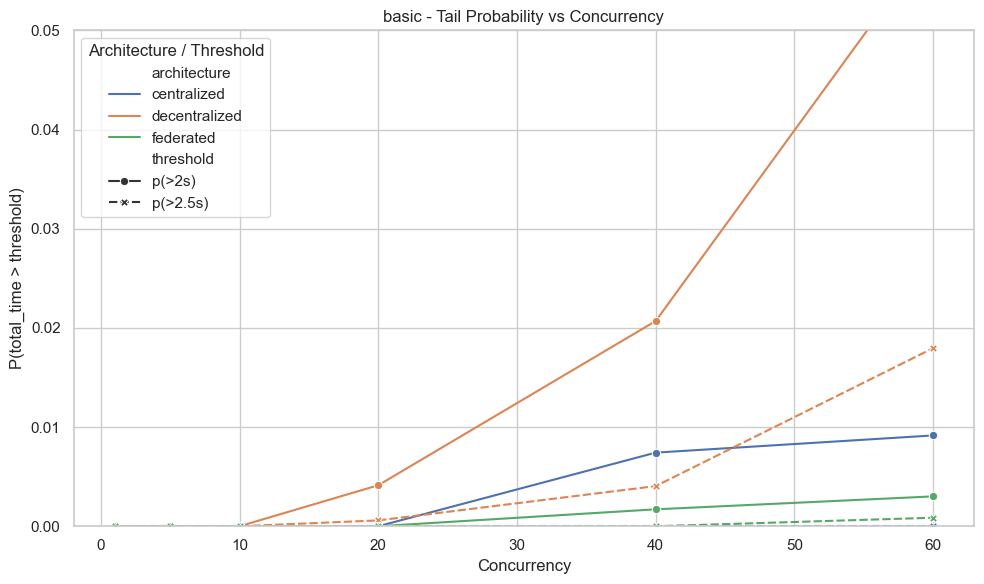

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置画图风格
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

fn = "basic"
df = all_data[all_data["fn_type"] == fn]

results = []

for (arch, conc), group in df.groupby(["architecture", "concurrency"]):
    p_gt_2s = (group["total_time"] > 2.0).mean()
    p_gt_2_5s = (group["total_time"] > 2.5).mean()
    results.append({
        "architecture": arch,
        "concurrency": conc,
        "p(>2s)": p_gt_2s,
        "p(>2.5s)": p_gt_2_5s
    })

prob_df = pd.DataFrame(results)
melted = prob_df.melt(id_vars=["architecture", "concurrency"], 
                      value_vars=["p(>2s)", "p(>2.5s)"], 
                      var_name="threshold", 
                      value_name="probability")

plt.figure(figsize=(10, 6))
sns.lineplot(data=melted, x="concurrency", y="probability", hue="architecture", style="threshold", markers=True)
plt.title(f"{fn} - Tail Probability vs Concurrency")
plt.xlabel("Concurrency")
plt.ylabel("P(total_time > threshold)")
plt.ylim(0, 0.05)
plt.legend(title="Architecture / Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()
